<a href="https://colab.research.google.com/github/MiguelAngeloTr/Deep_Learning/blob/main/C3/Gan_RED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trilema del modelo generativo
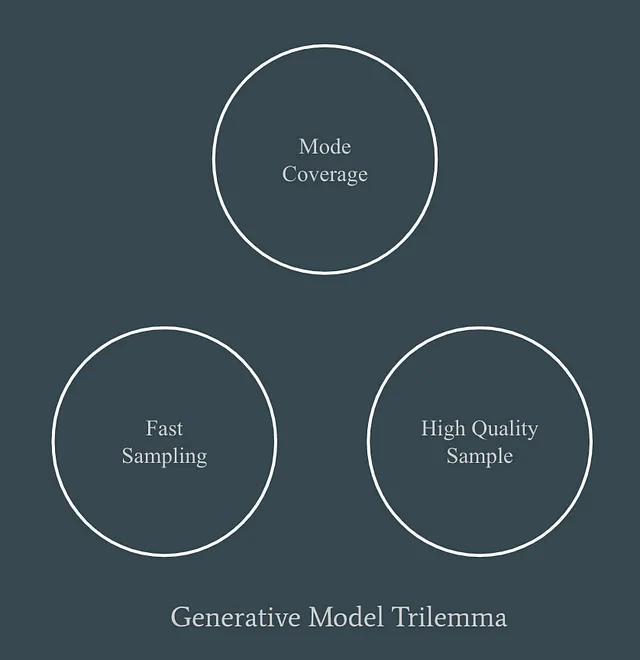

* Datos realistas y precisos en comparación con la distribución de datos reales
* Muestreo rápido (es decir, la velocidad de generación o escalabilidad)
* Cobertura de modo. No solo queremos aprender una parte específica de la distribución desconocida, sino que queremos capturar toda la distribución para garantizar la diversidad de la muestra. Por ejemplo, no queremos un modelo que solo genere imágenes de 0 y 1, sino todas las clases de dígitos posibles.

**Autoencoders variacionales**

Los codificadores automáticos son modelos de reducción de dimensionalidad que aprenden a comprimir datos en alguna representación latente.
Para ello codifican la entrada del decodificador como una distribución en el espacio latente

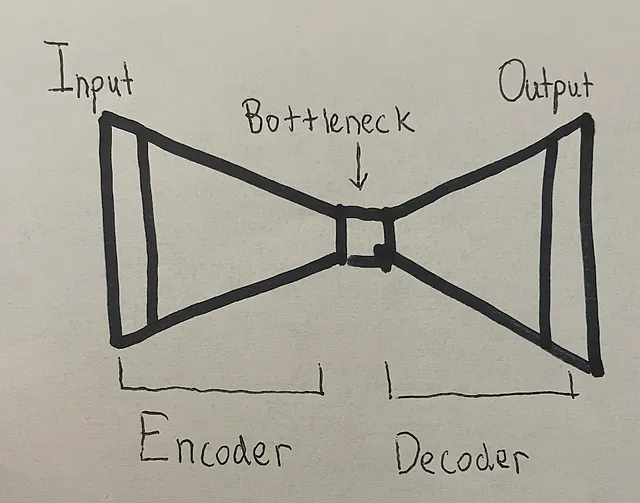

# Redes Generativas

En las GAN, hay un generador G y un discriminador D. El generador crea nuevos datos y el discriminador diferencia (o discrimina) entre datos reales y falsos. Los dos se entrenan uno contra el otro en un estilo de juego, de ahí el término adversario.

Recibimos algunos datos de entrenamiento y comenzamos muestreando ruido aleatorio z usando una distribución normal estándar o uniforme. Este ruido es la representación latente de los datos a generar. Comenzamos con ruido para permitir muestras de datos más diversas y evitar el sobreajuste.

El ruido se introduce en el generador, que genera los datos generados x = G(z). Luego, el discriminador toma x y genera P[x = real] = D(x), es decir, la probabilidad de que la imagen generada x sea una imagen real. Además, alimentamos al discriminador con una imagen real del conjunto de entrenamiento.

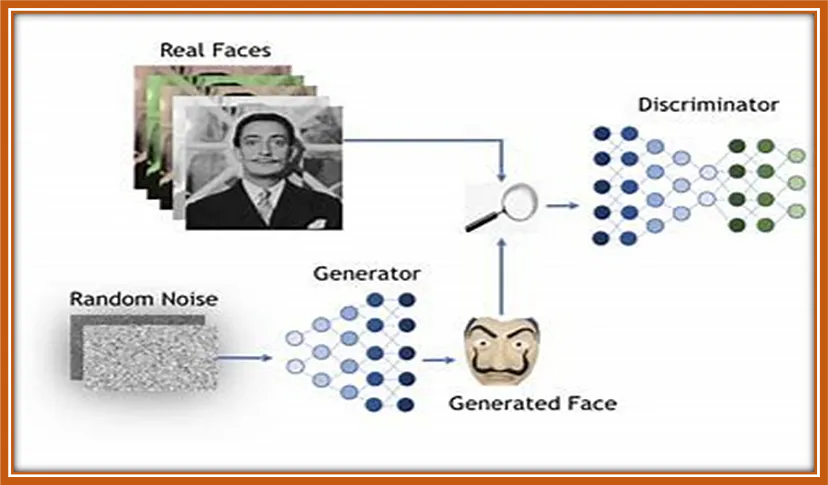

Imagine a las GAN como dos artistas rivales, uno creando arte falso y el otro tratando de distinguir entre lo real y lo falso.

El objetivo de las GAN es generar muestras de datos realistas y de alta calidad en diversos dominios, como imágenes, audio y texto. La red generadora crea nuevas muestras, mientras que la red discriminadora evalúa la autenticidad de las muestras generadas. Las dos redes se entrenan simultáneamente, de manera adversaria, con el generador intentando producir muestras más realistas y el discriminador mejorando en la detección de falsificaciones.

Los dos componentes principales de una GAN son:

* Generador: La red generadora es responsable de crear nuevas muestras. Toma un vector de ruido aleatorio como entrada y genera una muestra de salida, como una imagen o una oración. El generador está entrenado para producir muestras más realistas minimizando una función de pérdida que mide la diferencia entre las muestras generadas y los datos reales.

* Discriminador: La red discriminadora evalúa la autenticidad de las muestras generadas. Toma una muestra como entrada y genera una probabilidad que indica si la muestra es real o falsa. El discriminador está entrenado para distinguir entre muestras reales y falsas maximizando una función de pérdida que mide la diferencia entre la probabilidad de las muestras reales y las generadas.

La naturaleza contradictoria de las GAN surge de la competencia entre el generador y el discriminador. El generador intenta producir muestras más realistas para engañar al discriminador, mientras que el discriminador intenta mejorar su capacidad para distinguir muestras reales de falsas. Este proceso continúa hasta que el generador produce datos realistas y de alta calidad que no se pueden distinguir fácilmente de los datos reales.

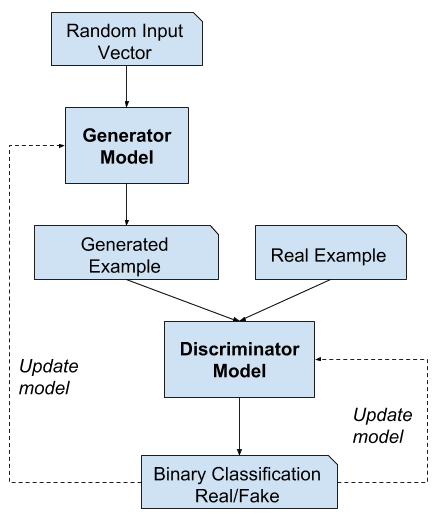

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
%cd /content/gdrive/My\ Drive/

/content/gdrive/My Drive


In [ ]:
!mkdir gan_red

mkdir: cannot create directory ‘gan_red’: File exists


In [ ]:
%cd gan_red

/content/gdrive/My Drive/gan_red


In [ ]:
import keras
from keras.layers import Dense, Conv2DTranspose, LeakyReLU, Reshape, BatchNormalization, Activation, Conv2D
from keras.models import Model, Sequential


def generador_de_imagenes():
   #El generador basicamente es un modelo sencillo en forma de piramide inversa
   #similar al decodificador o el decoder en los autoencoders convolucional
   #La entrada tiene una dimension de 100,1 lo que quiere decir que es un
   #vector con 100, estos 100 datos representan al espacio latente del generador
   #a la salidad del generador tenemos una estrucutra del tipo de dato que queremos
   #genera, para este ejemplo una imagen 32X32x3

    generador = Sequential()

    generador.add(Dense(256*4*4, input_shape = (100,)))
    #generador.add(BatchNormalization())
    generador.add(LeakyReLU())
    generador.add(Reshape((4,4,256)))

    generador.add(Conv2DTranspose(128,kernel_size=3, strides=2, padding = "same"))
    #generador.add(BatchNormalization())
    generador.add(LeakyReLU(alpha=0.2))


    generador.add(Conv2DTranspose(128,kernel_size=3, strides=2, padding = "same"))
    #generador.add(BatchNormalization())
    generador.add(LeakyReLU(alpha=0.2))

    generador.add(Conv2DTranspose(128,kernel_size=3, strides=2, padding = "same"))
    #generador.add(BatchNormalization())
    generador.add(LeakyReLU(alpha=0.2))

    generador.add(Conv2D(3,kernel_size=3, padding = "same", activation='tanh'))

    return(generador)

modelo_generador = generador_de_imagenes()

modelo_generador.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4096)                │         413,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 8, 8, 128)           │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 3)           │           3,459 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,007,363 (3.84 MB)

 Trainable params: 1,007,363 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
#Creamos datos aleatorios que siguen a una distribucción normal
# y predecimos, para retornarnos tres imagenes (por el batch) 32x32x3
i = np.random.randn(300)
print(i.shape)
i = i.reshape(3,100)
print(i.shape)
img= modelo_generador.predict(i)
print(img.shape)

(300,)
(3, 100)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(3, 32, 32, 3)


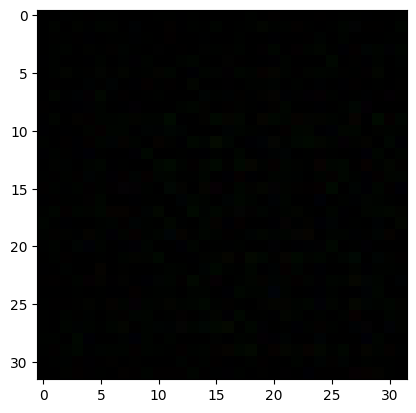

In [ ]:
import matplotlib.pyplot as plt
#visualizamos la imagen con imshow
plt.imshow(img[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


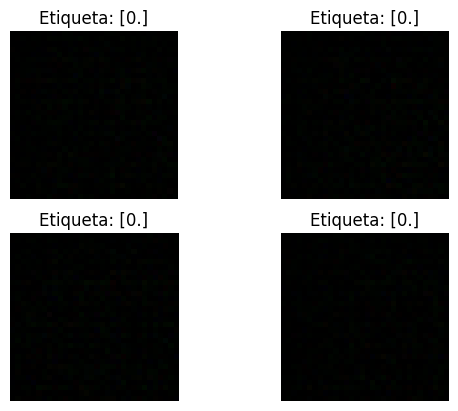

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definir datos de entrada
def generar_datos_entrada(n_muestras):
  #creamos una funcion que genera n muestras de ruido aleatorio, cada muestra tiene 100 datos

  X = np.random.randn(100 * n_muestras)
  X = X.reshape(n_muestras, 100)
  return X

def crear_datos_fake(modelo_generador, n_muestras):
  #Generamos n muestras, las cuales se predeciran por el modelo generador
  #estas prediciones son imagenes como las que se mostraron al comienzo
  #y obtenemos una matriz de etiquetas 'y' que corresponderan a los datos
  #falsos (matriz o vector de n muestras x 1), es decir estamos generando datos que el discriminador debera de
  # detectar como faltos
  input = generar_datos_entrada(n_muestras)
  X = modelo_generador.predict(input)
  y = np.zeros((n_muestras, 1))
  return X,y

numero_muestras = 4
X,y = crear_datos_fake(modelo_generador, numero_muestras)

# Visualizamos resultados
for i in range(numero_muestras):
    plt.subplot(2, 2, 1 + i)
    plt.title(f'Etiqueta: {y[i]}')
    plt.axis('off')
    plt.imshow(X[i])

In [ ]:
from tensorflow.keras.layers import Conv2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
def discriminador_de_imagenes():

  #El discriminador es una red convolucional dedicada a clasificar, tiene una estructura
  #similar a las redes vistas anteriomente, la entrada sera la imagen generada por el
  #generador por consiguiente debera de ser una imagen de 32x32x3 y la salida sera una
  #capa sigmoide que trenda un valor binario, 1 o 0 dependiendo si la imagen del generador
  #es verdadera o falsa... mas adelante buscaremos engañar a este modelo

    discriminador = Sequential()
    discriminador.add(Conv2D(64, kernel_size=3, padding = "same", input_shape = (32,32,3)))
    discriminador.add(LeakyReLU(alpha=0.2))
    #discriminador.add(Dropout(0.2))

    discriminador.add(Conv2D(128, kernel_size=3,strides=(2,2), padding = "same"))
    discriminador.add(LeakyReLU(alpha=0.2))
    #discriminador.add(Dropout(0.2))

    discriminador.add(Conv2D(128, kernel_size=3,strides=(2,2), padding = "same"))
    discriminador.add(LeakyReLU(alpha=0.2))
    #discriminador.add(Dropout(0.2))

    discriminador.add(Conv2D(256, kernel_size=3, strides=(2,2), padding = "same"))
    discriminador.add(LeakyReLU(alpha=0.2))
    #discriminador.add(Dropout(0.2))

    discriminador.add(Flatten())
    discriminador.add(Dropout(0.4))
    discriminador.add(Dense(1, activation='sigmoid'))

    opt = Adam(learning_rate=0.0002 ,beta_1=0.5)
    discriminador.compile(loss='binary_crossentropy', optimizer= opt , metrics = ['accuracy'])

    return(discriminador)

modelo_discriminador = discriminador_de_imagenes()
modelo_discriminador.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_10 (LeakyReLU)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_11 (LeakyReLU)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │           4,097 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.datasets import cifar10

def cargar_imagenes():
  #se carga el dataset cifar10, se extraen solamente las imagenes de una clase,
  #para este ejemplo es la clase 0
    (Xtrain, Ytrain), (_, _) = cifar10.load_data()

    # Nos quedamos con
    indice = np.where(Ytrain == 0)
    indice = indice[0]
    Xtrain = Xtrain[indice, :,:,:]

    # Normalizamos los datos
    X = Xtrain.astype('float32')
    X = (X - 127.5) / 127.5
    #255-127.5/127.5 =1   0-127.7/127.5= -1

    return X

print(cargar_imagenes().shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(5000, 32, 32, 3)


In [ ]:
dataset = cargar_imagenes()

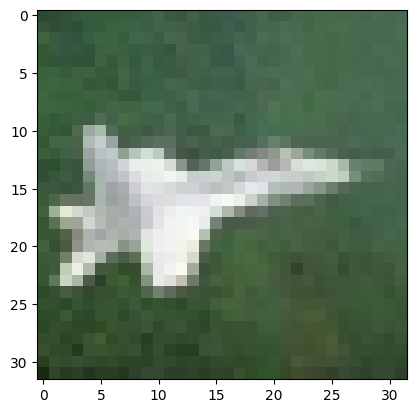

In [ ]:
x_1 = (dataset[4] +1) /2.0   # -1->0 -1+1/2    1->1  1+1 /2 para poder visualisar la imagen normalizamos dividiendo entre 2, de tal  manera que
# los valores -1 se convierta en 0 y 1 continua siendo 1
plt.imshow(x_1)

In [ ]:
import random

def cargar_datos_reales(dataset, n_muestras):
  #Creamos una funcion que cargara los datos reales del dataset cifar10, selecionamos n muestras aleatorios de nuestro
  #dataset y los etiquetara como 1
  ix = np.random.randint(0, dataset.shape[0], n_muestras)
  X = dataset[ix]
  y = np.ones((n_muestras, 1))
  return X,y

def cargar_datos_fake(n_muestras):
  #Creamos n muestras de ruido que siguen una distribución normal, similar a las imagenes que generabamos arriba y creamos nuestro
  #vector de etiquetas asociados a 0
  X = np.random.rand(32 * 32 * 3 * n_muestras)
  X = -1 + X * 2
  X = X.reshape((n_muestras, 32,32,3))
  y = np.zeros((n_muestras, 1))
  return X,y


In [ ]:
def entrenar_discriminador(modelo, dataset, n_iteraciones=20, batch = 128):

  #En esta funcion entrenaremos al discriminador, estre entrenamiento sera 50% datos
  #datos reales y 50% datos falsos, este proceso es basicamenta para que en discriminador
  #comprenda cuales son las imagenes reales y cuales son las falsas
  medio_batch = int(batch/2)

  for i in range(n_iteraciones):
    X_real, y_real = cargar_datos_reales(dataset, medio_batch)
    _, acc_real = modelo.train_on_batch(X_real, y_real)

    X_fake, y_fake = cargar_datos_fake(medio_batch)
    _, acc_fake = modelo.train_on_batch(X_fake, y_fake)

    print(str(i+1) + ' Real:' + str(acc_real*100) + ', Fake:' + str(acc_fake*100))

In [ ]:
#dataset = cargar_imagenes()
entrenar_discriminador(modelo_discriminador, dataset)

1 Real:95.3125, Fake:47.65625


2 Real:65.10416865348816, Fake:48.828125


3 Real:59.062498807907104, Fake:49.47916865348816
4 Real:56.6964328289032, Fake:51.953125
5 Real:56.9444477558136, Fake:58.43750238418579
6 Real:61.64773106575012, Fake:64.84375
7 Real:66.5865421295166, Fake:68.97321939468384
8 Real:70.10416984558105, Fake:71.97265625
9 Real:72.24264740943909, Fake:73.78472089767456
10 Real:74.67105388641357, Fake:75.93750357627869
11 Real:76.63690447807312, Fake:77.6988685131073
12 Real:78.39674353599548, Fake:79.296875
13 Real:79.87499833106995, Fake:80.6490421295166
14 Real:81.30787014961243, Fake:81.97544813156128
15 Real:82.54310488700867, Fake:83.12500715255737
16 Real:83.61895084381104, Fake:84.130859375
17 Real:84.51704382896423, Fake:84.9724292755127
18 Real:85.31249761581421, Fake:85.72048544883728
19 Real:86.10641360282898, Fake:86.47204041481018
20 Real:86.81890964508057, Fake:87.14843988418579


In [ ]:
def crear_gan(discriminador, generador):
  #Con el discriminador ya entrenado, creamos la red completa,que seria la GAN propiamente dicha,
  #note que aqui no vamos a entrenar al discrimiador, esta vez entrenamos al generador para que logre
  #engañare al discriminador
    discriminador.trainable=False #no entrenar los pesos del discriminador
    gan = Sequential()
    gan.add(generador)
    gan.add(discriminador)

    opt = Adam(learning_rate=0.0002,beta_1=0.5)
    gan.compile(loss = "binary_crossentropy", optimizer = opt)

    return gan

gan = crear_gan(modelo_discriminador,modelo_generador)
gan.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 32, 32, 3)           │       1,007,363 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_2 (Sequential)            │ (None, 1)                   │         522,497 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,529,860 (5.84 MB)

 Trainable params: 1,007,363 (3.84 MB)

 Non-trainable params: 522,497 (1.99 MB)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime

def mostrar_imagenes_generadas(datos_fake, epoch):

  #creamos una funcion para ver el progreso de las imagenes generadas por el generador

  now = datetime.now()
  now = now.strftime("%Y%m%d_%H%M%S")

  # Hacemos que los datos vayan de 0 a 1
  datos_fake = (datos_fake + 1) / 2.0

  for i in range(10):
    plt.imshow(datos_fake[i])
    plt.axis('off')
    nombre = str(epoch) + '_imagen_generada_' + str(i) + '.png'
    plt.savefig(nombre, bbox_inches='tight')
    plt.close()

In [ ]:
def evaluar_y_guardar(modelo_generador, epoch, medio_dataset):
  #esta funcion nos permite guardar los pesos del modelo a medida que el entrenamiento avanza,
  #recuerde que esta ves los pesos guardados seran los del generador que a priori es el modelo
  #que nos interesa

  # Guardamos el modelo
  now = datetime.now()
  now = now.strftime("%Y%m%d_%H%M%S")
  nombre = str(epoch) + '_' + str(now)+"_modelo_generador_" + '.h5'
  modelo_generador.save(nombre)

  # Generamos nuevos datos
  X_real,Y_real = cargar_datos_reales(dataset, medio_dataset)
  X_fake, Y_fake =  crear_datos_fake(modelo_generador,medio_dataset)

  # Evaluamos el modelo
  _, acc_real = modelo_discriminador.evaluate(X_real, Y_real)
  _, acc_fake = modelo_discriminador.evaluate(X_fake, Y_fake)

  print('Acc Real:' + str(acc_real*100) + '% Acc Fake:' + str(acc_fake*100)+'%')

In [ ]:
def entrenamiento(datos, modelo_generador, modelo_discriminador, epochs, n_batch, inicio = 0):
  dimension_batch = int(datos.shape[0]/n_batch)
  medio_dataset = int(n_batch/2)

  # Iteramos para todos los epochs
  for epoch in range(inicio, inicio + epochs):
    # Iteramos para todos los batches
    for batch in range(n_batch):

      # Cargamos datos reales
      X_real,Y_real = cargar_datos_reales(dataset, medio_dataset)


      # Enrenamos discriminador con datos reales
      coste_discriminador_real, _ = modelo_discriminador.train_on_batch(X_real, Y_real)

      # Cargamos datos falsos
      X_fake, Y_fake =  crear_datos_fake(modelo_generador,medio_dataset)

      # Enrenamos discriminador con datos falsos
      coste_discriminador_fake, _ = modelo_discriminador.train_on_batch(X_fake, Y_fake)

      # Generamos datos de entradas de la GAN
      X_gan = generar_datos_entrada(medio_dataset)
      Y_gan = np.ones((medio_dataset, 1))

      # Entrenamos la GAN con datos falsos
      coste_gan = gan.train_on_batch(X_gan, Y_gan)

    # Cada 10 Epochs mostramos resultados y el coste
    if (epoch+1) % 10 == 0:
      evaluar_y_guardar(modelo_generador,epoch = epoch, medio_dataset= medio_dataset)
      mostrar_imagenes_generadas(X_fake, epoch = epoch)

In [ ]:
entrenamiento(dataset, modelo_generador, modelo_discriminador, epochs = 50, n_batch=128, inicio = 0)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━

In [ ]:
X_fake, _ = crear_datos_fake(n_muestras=10, modelo_generador=modelo_generador)
X_fake = (X_fake+1)/2

for i in range(10):
  plt.subplot(7,7,i+1)
  plt.axis('off')
  plt.imshow(X_fake[i])

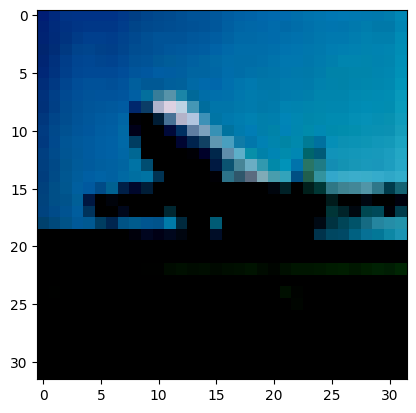

In [ ]:
plt.imshow(dataset[100])

1/1 [==============================] - 0s 21ms/step


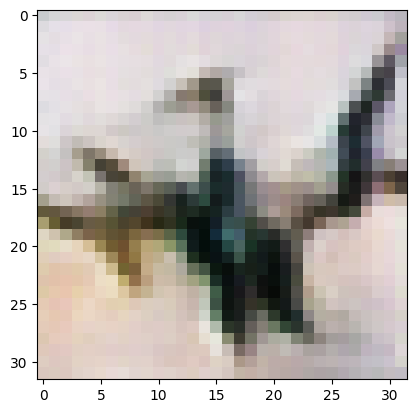

In [ ]:
i = np.random.randn(100)
i= i.reshape(1,100)
img= modelo_generador.predict(i)
plt.imshow((img[0]+1)/2.0)

In [ ]:


###
#Si se acaba la sesión
from google.colab import drive
import os
drive.mount('/content/gdrive/')
%cd /content/gdrive/MyDrive/gan_red

# 2. Importamos el modelo
from keras.models import load_model

modelo_generador = load_model('/content/gdrive/MyDrive/gan_red/49_20240514_143914_modelo_generador_.h5')


Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
/content/gdrive/MyDrive/gan_red
